# Modélisation : House Prices

## Objectif
Entraîner un modèle de régression linéaire sur les features préparées, évaluer ses performances, vérifier les hypothèses du modèle (résidus), et sauvegarder le modèle final pour l'utiliser via une API.

## Étapes
1. Chargement du dataset final
2. Séparation features / cible et split train/test
3. Entraînement du modèle
4. Évaluation (MAE, RMSE, R²)
5. Analyse des résidus
6. Interprétation des coefficients
7. Sauvegarde du modèle

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv('../data/processed/train_final.csv')
print(df.shape)
df.head()

(1458, 239)


,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond,BsmtQual,...,MSSubClass_30,MSSubClass_40,MSSubClass_45,MSSubClass_50,MSSubClass_60,MSSubClass_70,MSSubClass_75,MSSubClass_80,MSSubClass_85,MSSubClass_90
0,65.0,8450,7,5,2003,2003,196.0,4,3,4,...,False,False,False,False,True,False,False,False,False,False
1,80.0,9600,6,8,1976,1976,0.0,3,3,4,...,False,False,False,False,False,False,False,False,False,False
2,68.0,11250,7,5,2001,2002,162.0,4,3,4,...,False,False,False,False,True,False,False,False,False,False
3,60.0,9550,7,5,1915,1970,0.0,3,3,3,...,False,False,False,False,False,True,False,False,False,False
4,84.0,14260,8,5,2000,2000,350.0,4,3,4,...,False,False,False,False,True,False,False,False,False,False


In [4]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)
df[bool_cols].head()

""
0
1
2
3
4


In [7]:
X = df.drop(columns=['SalePrice_log'])
Y = df['SalePrice_log']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print('Train: ', X_train.shape)
print('Test: ', X_test.shape)

Train:  (1166, 238)
Test:  (292, 238)


In [9]:
model = LinearRegression()
model.fit(X_train, Y_train)
print('Modèle entrainé')

Modèle entrainé


In [10]:
Y_pred = model.predict(X_test)
mae = mean_absolute_error(Y_test, Y_pred)
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
r2 = r2_score(Y_test, Y_pred)
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

MAE: 0.0898
RMSE: 0.1304
R²: 0.8992


In [12]:
y_test_dollars = np.expm1(Y_test)
y_pred_dollars = np.expm1(Y_pred)

mae_dollars = mean_absolute_error(y_test_dollars, y_pred_dollars)
print(f"MAE en dollars : {mae_dollars:.2f}")

MAE en dollars : 15434.02


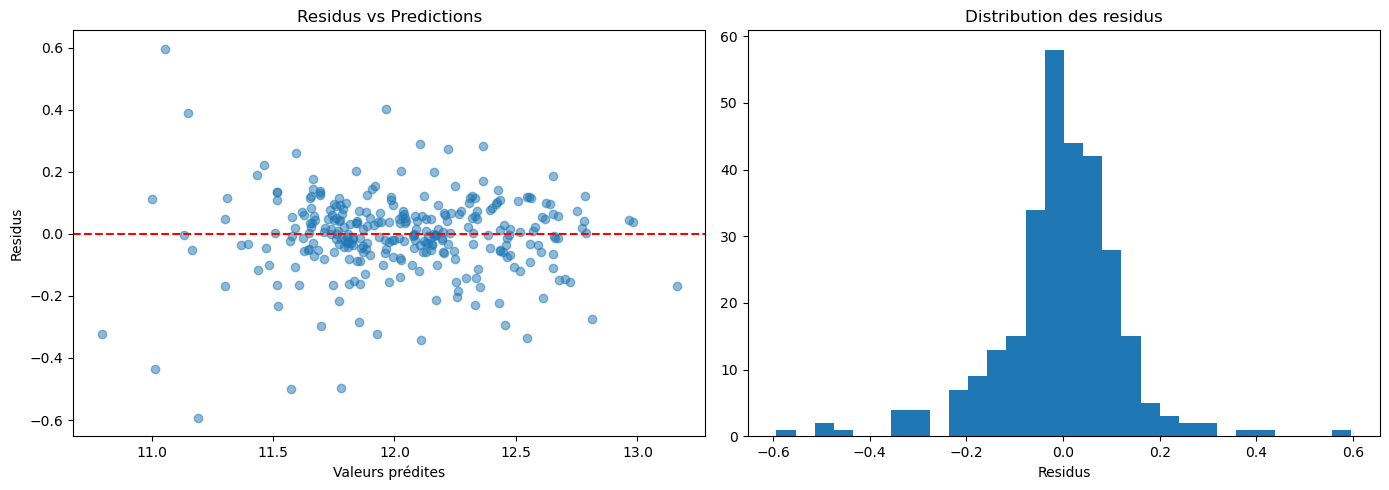

In [15]:
residuals = Y_test - Y_pred
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(Y_pred, residuals, alpha=0.5)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Valeurs prédites')
axes[0].set_ylabel('Residus')
axes[0].set_title('Residus vs Predictions')

axes[1].hist(residuals, bins=30)
axes[1].set_xlabel('Residus')
axes[1].set_title('Distribution des residus')

plt.tight_layout()
plt.show()

In [16]:
coefficients = pd.Series(model.coef_, index=X.columns).sort_values(ascending=False)

print("Top 10 variables qui augmentent le prix :")
print(coefficients.head(10))

print("\nTop 10 variables qui diminuent le prix :")
print(coefficients.tail(10))

Top 10 variables qui augmentent le prix :
MSZoning_FV          0.454886
Condition2_PosA      0.444211
SaleType_New         0.434740
MSZoning_RL          0.403433
MSZoning_RH          0.380808
Condition2_RRNn      0.331811
MSZoning_RM          0.329470
Condition2_Feedr     0.321817
GarageType_None      0.281294
GarageFinish_None    0.281294
dtype: float64

Top 10 variables qui diminuent le prix :
MSSubClass_45           -0.117700
Foundation_Wood         -0.117807
LandSlope_Sev           -0.130901
MiscFeature_Othr        -0.159115
Exterior2nd_Other       -0.180005
Utilities_NoSeWa        -0.237951
Functional_Maj2         -0.281751
MiscFeature_TenC        -0.284288
SaleCondition_Partial   -0.331872
Exterior1st_BrkComm     -0.357961
dtype: float64


In [17]:
garage_redundant = [col for col in X.columns if col.startswith('GarageQual') 
                     or col.startswith('GarageCond') 
                     or col.startswith('GarageType') 
                     or col.startswith('GarageFinish')] + ['GarageYrBlt']

print(garage_redundant)

['GarageQual', 'GarageCond', 'GarageType_Attchd', 'GarageType_Basment', 'GarageType_BuiltIn', 'GarageType_CarPort', 'GarageType_Detchd', 'GarageType_None', 'GarageFinish_None', 'GarageFinish_RFn', 'GarageFinish_Unf', 'GarageYrBlt']


In [19]:
X_v2 = X.drop(columns=garage_redundant)
X_train_v2, X_test_v2, Y_train, Y_test = train_test_split(X_v2, Y, test_size=0.2, random_state=42)
model_v2 = LinearRegression()
model_v2.fit(X_train_v2, Y_train)
Y_pred_v2 = model_v2.predict(X_test_v2)

mae_v2 = mean_absolute_error(Y_test, Y_pred_v2)
rmse_v2 = np.sqrt(mean_squared_error(Y_test, Y_pred_v2))
r2_v2 = r2_score(Y_test, Y_pred_v2)

print(f"MAE: {mae_v2:.4f}")
print(f"RMSE: {rmse_v2:.4f}")
print(f"R²: {r2_v2:.4f}")

MAE: 0.0895
RMSE: 0.1301
R²: 0.8995


In [20]:
coefficients_v2 = pd.Series(model_v2.coef_, index=X_v2.columns).sort_values(ascending=False)
print(coefficients_v2[coefficients_v2.index.str.contains('Garage')])

GarageCars    0.046658
dtype: float64


In [24]:
from sklearn.linear_model import Ridge

model_ridge = Ridge(alpha=10)
model_ridge.fit(X_train_v2, Y_train)

y_pred_ridge = model_ridge.predict(X_test_v2)

mae_ridge = mean_absolute_error(Y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(Y_test, y_pred_ridge))
r2_ridge = r2_score(Y_test, y_pred_ridge)

print(f"MAE : {mae_ridge:.4f}")
print(f"RMSE : {rmse_ridge:.4f}")
print(f"R2 : {r2_ridge:.4f}")

MAE : 0.0833
RMSE : 0.1227
R2 : 0.9107


In [25]:
coefficients_ridge = pd.Series(model_ridge.coef_, index=X_v2.columns).sort_values(ascending=False)

print("Top 10 qui augmentent le prix :")
print(coefficients_ridge.head(10))

print("\nTop 10 qui diminuent le prix :")
print(coefficients_ridge.tail(10))

Top 10 qui augmentent le prix :
Neighborhood_StoneBr    0.077393
Neighborhood_Crawfor    0.077279
SaleType_New            0.064570
SaleCondition_Normal    0.060363
Functional_Typ          0.059802
CentralAir_Y            0.059652
Exterior1st_BrkFace     0.057597
MSZoning_FV             0.053336
Condition1_Norm         0.053213
MSZoning_RL             0.052118
dtype: float64

Top 10 qui diminuent le prix :
Condition1_RRAe        -0.034512
Functional_Mod         -0.034527
Neighborhood_Edwards   -0.035608
LandSlope_Sev          -0.038473
MSSubClass_30          -0.038918
BldgType_Twnhs         -0.042203
Functional_Maj2        -0.042421
Heating_Grav           -0.044788
MSSubClass_160         -0.054924
Neighborhood_MeadowV   -0.060439
dtype: float64


In [26]:
import joblib

joblib.dump(model_ridge, '../src/model_ridge.pkl')
joblib.dump(X_v2.columns.tolist(), '../src/model_columns.pkl')

print("Modele et colonnes sauvegardes")

Modele et colonnes sauvegardes
